In [1]:
!pip install unidecode -q
!pip install rdkit -q

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import unidecode
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import json
import csv
import re
import gzip
import urllib.request
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, QED, AllChem, DataStructs
import warnings
warnings.filterwarnings('ignore')

TOKENIZER_NAME = "atom-level"  

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [4]:
# Load and preprocess data
try:
    text = unidecode.unidecode(open('data_for_generation_mol.txt').read())
except:
    print("⚠️ Data file not found. Please update the file path.")

print(f"📊 Total characters in dataset: {len(text):,}")
print(f"🔤 First 100 characters: {text[:100]}")
print(f"🧪 Number of molecules (approx, by '<' count): {text.count('<'):,}")

📊 Total characters in dataset: 75,602,998
🔤 First 100 characters: <COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56><C[S+]
🧪 Number of molecules (approx, by '<' count): 1,498,669


In [5]:
ATOM_LEVEL_PATTERN = re.compile(
    r"(\[[^\]]+\]"        # bracket atoms: [nH], [Fe2+], [O-], [C@@H], etc.
    r"|Br|Cl|Si|Se|se|As|Te|te|Sb|Sn|Mg|Zn|Ca|Na|Li"  # common 2-char elements/metals
    r"|@@|@"              # stereochemistry
    r"|%[0-9]{2}"         # two-digit ring closure numbers, e.g. %10, %23
    r"|.)"                # fallback: any single character (aromatic atoms, single-char elements, bonds, digits, brackets/parens)
)

def atom_level_tokenize(smiles_string):
    return ATOM_LEVEL_PATTERN.findall(smiles_string)

print("🔬 Running atom-level (regex-based) tokenization...")
tokens = atom_level_tokenize(text)
print(f"   Total tokens: {len(tokens):,}")
print(f"   Example (first 30): {tokens[:30]}")

🔬 Running atom-level (regex-based) tokenization...
   Total tokens: 70,628,770
   Example (first 30): ['<', 'C', 'O', 'c', '1', 'c', 'c', 'c', '2', '[C@@H]', '3', '[C@H]', '(', 'C', 'O', 'c', '2', 'c', '1', ')', 'C', '(', 'C', ')', '(', 'C', ')', 'O', 'C', '4']


In [6]:
# Extract unique tokens and build vocabulary
chars = sorted(set(tokens))
vocab_size = len(chars)
print(f"\n📚 Vocabulary ({vocab_size} tokens): {chars}")
print(f"📏 Vocabulary size: {vocab_size}")


📚 Vocabulary (225 tokens): ['#', '%10', '%11', '%12', '%13', '(', ')', '.', '/', '1', '2', '3', '4', '5', '6', '7', '8', '9', '<', '=', '>', 'B', 'Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S', 'Sn', '[11C-]', '[11C@H]', '[11CH2]', '[11CH3]', '[11CH]', '[11C]', '[11c]', '[123I-]', '[123I]', '[123Te]', '[124I]', '[125I-]', '[125IH]', '[125I]', '[127I]', '[127Xe]', '[131I-]', '[131I]', '[133Xe]', '[135I]', '[13CH]', '[13C]', '[13NH3]', '[14C@@H]', '[14C@@]', '[14C@H]', '[14CH2]', '[14CH3]', '[14CH]', '[14C]', '[14cH]', '[14c]', '[15NH]', '[15N]', '[15OH2]', '[15n]', '[17F]', '[18F-]', '[18F]', '[18OH]', '[18O]', '[19F]', '[1H]', '[223Ra+2]', '[22Na+]', '[2H]', '[32PH]', '[32P]', '[35S]', '[3H]', '[42K+]', '[45Ca+2]', '[47Ca+2]', '[73Se]', '[75Se]', '[76Br-]', '[76Br]', '[81Kr]', '[82Rb+]', '[85Sr+2]', '[85Sr]', '[89Sr+2]', '[Ag+]', '[AgH3-4]', '[Ag]', '[Al+3]', '[Al-3]', '[Al]', '[As+]', '[As-]', '[AsH3]', '[As]', '[B-]', '[BH-]', '[BH2-]', '[BH3-]', '[B]', '[Ba+2]', '[Be+2]', '[Bi+3]', 

In [7]:
# Create token mappings
stoi = {tok: i for i, tok in enumerate(chars)}
itos = {i: tok for i, tok in enumerate(chars)}

def encode(s):
    toks = atom_level_tokenize(s)
    return [stoi[t] for t in toks]

def decode(l):
    return ''.join(itos[i] for i in l)

# Test encoding/decoding
sample_text = text[:200]
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"Original: {sample_text}")
print(f"Encoded ({len(encoded)} tokens): {encoded[:20]}...")
print(f"Decoded: {decoded}")
print(f"✅ Round-trip works: {sample_text == decoded}")

# Verification test: Cl / Br must stay as single tokens (not split into C+l)
test_case = "ClC(=O)O"
test_tokens = atom_level_tokenize(test_case)
expected = ['Cl', 'C', '(', '=', 'O', ')', 'O']
print(f"\n🧪 Verification: '{test_case}' -> {test_tokens}")
print(f"✅ Matches expected atom-level split: {test_tokens == expected}")
assert test_tokens == expected, "Atom-level tokenizer regex is not working as expected!"


Original: <COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56><C[S+]([O-])c1ccc(cc1)c2nc(c3ccc(F)cc3)c([nH]2)c4ccncc4><CC1(C)Oc2ccc(cc2[C@H]([C@@H]1O)N3CCCC3=O)C#N><OC(
Encoded (164 tokens): [18, 23, 28, 220, 9, 220, 220, 220, 10, 115, 11, 117, 5, 23, 28, 220, 10, 220, 9, 6]...
Decoded: <COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56><C[S+]([O-])c1ccc(cc1)c2nc(c3ccc(F)cc3)c([nH]2)c4ccncc4><CC1(C)Oc2ccc(cc2[C@H]([C@@H]1O)N3CCCC3=O)C#N><OC(
✅ Round-trip works: True

🧪 Verification: 'ClC(=O)O' -> ['Cl', 'C', '(', '=', 'O', ')', 'O']
✅ Matches expected atom-level split: True


In [8]:
# Encode entire dataset
data = torch.tensor(encode(text), dtype=torch.long)
print(f"\n📈 Dataset shape: {data.shape}, dtype: {data.dtype}")
print(f"📊 First 20 tokens: {data[:20].tolist()}")


📈 Dataset shape: torch.Size([70628770]), dtype: torch.int64
📊 First 20 tokens: [18, 23, 28, 220, 9, 220, 220, 220, 10, 115, 11, 117, 5, 23, 28, 220, 10, 220, 9, 6]


## Data Splitting and Batch Generation

In [9]:
# Hyperparameters (fixed across ALL tokenizer conditions for a fair, controlled comparison)
batch_size = 32
block_size = 256
learning_rate = 1e-4
n_head = 12
n_embd = n_head * 32
ff_size_factor = 4
n_layer = 12
dropout = 0.15

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Using device: {device}")

🖥️ Using device: cuda


In [11]:
# Split data into train/validation
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"📊 Train data: {len(train_data):,} tokens")
print(f"📊 Val data: {len(val_data):,} tokens")

📊 Train data: 63,565,893 tokens
📊 Val data: 7,062,877 tokens


In [12]:
def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [13]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, ff_size_factor * n_embd),
            nn.GELU(),
            nn.Linear(ff_size_factor * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class DrugGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens, eos_token, temperature=1.0, top_k=None):
        self.eval()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                idx_cond = idx[:, -block_size:]
                logits, _ = self(idx_cond)
                logits = logits[:, -1, :] / temperature
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)
                if idx_next.item() == eos_token:
                    break
                idx = torch.cat((idx, idx_next), dim=1)
        self.train()
        return idx

model = DrugGPT()
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔧 Model created successfully!")
print(f"📊 Total parameters: {total_params/1e6:.2f}M")
print(f"🏋️ Trainable parameters: {trainable_params/1e6:.2f}M")
print(f"💾 Model size: ~{total_params * 4 / 1e6:.1f}MB")

🔧 Model created successfully!
📊 Total parameters: 21.55M
🏋️ Trainable parameters: 21.55M
💾 Model size: ~86.2MB


In [14]:
# Training hyperparameters
max_iters = 25000          # same across all 10 conditions, for a fair controlled comparison
eval_interval = 200
eval_iters = 100
save_interval = 1000
save_path = f"drugGPT_{TOKENIZER_NAME}.pt"

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=learning_rate*0.1)

# --- Effective epoch calculation ---
tokens_per_step = batch_size * block_size
total_tokens_sampled = tokens_per_step * max_iters
effective_epochs = total_tokens_sampled / len(train_data)
estimated_unique_coverage = 1 - math.exp(-total_tokens_sampled / len(train_data))

print(f"📐 Tokenizer: {TOKENIZER_NAME}")
print(f"📐 Vocabulary size: {vocab_size}")
print(f"📐 Training set size: {len(train_data):,} tokens")
print(f"📐 Tokens sampled per training step: {tokens_per_step:,}")
print(f"📐 Total tokens sampled over {max_iters:,} steps: {total_tokens_sampled:,}")
print(f"📐 Effective epochs (tokens sampled / train set size): {effective_epochs:.2f}")
print(f"📐 Estimated unique-position coverage: {estimated_unique_coverage*100:.1f}%")

training_config = {
    "tokenizer": TOKENIZER_NAME,
    "vocab_size": vocab_size,
    "train_set_size_tokens": len(train_data),
    "val_set_size_tokens": len(val_data),
    "batch_size": batch_size,
    "block_size": block_size,
    "learning_rate": learning_rate,
    "n_head": n_head,
    "n_embd": n_embd,
    "n_layer": n_layer,
    "dropout": dropout,
    "optimizer": "AdamW",
    "weight_decay": 0.01,
    "lr_scheduler": "CosineAnnealingLR",
    "max_iters": max_iters,
    "effective_epochs": round(effective_epochs, 3),
    "estimated_unique_coverage_pct": round(estimated_unique_coverage*100, 2),
    "total_params_M": round(total_params/1e6, 3),
}
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"\n💾 Saved training_config_{TOKENIZER_NAME}.json")

📐 Tokenizer: atom-level
📐 Vocabulary size: 225
📐 Training set size: 63,565,893 tokens
📐 Tokens sampled per training step: 8,192
📐 Total tokens sampled over 25,000 steps: 204,800,000
📐 Effective epochs (tokens sampled / train set size): 3.22
📐 Estimated unique-position coverage: 96.0%

💾 Saved training_config_atom-level.json


In [15]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def generate_smiles(model, n_samples=100, temperature=0.8, max_length=100):
    sos_token = encode('<')[0]
    eos_token = encode('>')[0]
    generated_smiles = []
    context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
    for i in range(n_samples):
        try:
            generated = model.generate(context, max_new_tokens=max_length, eos_token=eos_token,
                                        temperature=temperature, top_k=50)
            smi = decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()
            if smi and len(smi) > 5:
                generated_smiles.append(smi)
        except Exception:
            continue
    return generated_smiles

🚀 Starting training for 25000 iterations...
📊 Batch size: 32, Block size: 256
🧠 Model: 21.6M parameters
Step     0 | Train: 5.3240 | Val: 5.3219 | LR: 1.00e-04 | Time: 97.6s
💾 Checkpoint saved at iteration 0
Step   200 | Train: 1.6596 | Val: 1.6992 | LR: 1.00e-04 | Time: 678.7s
Step   400 | Train: 1.4480 | Val: 1.4845 | LR: 9.99e-05 | Time: 1337.1s
Step   600 | Train: 1.1734 | Val: 1.2216 | LR: 9.99e-05 | Time: 1940.6s
Step   800 | Train: 1.0517 | Val: 1.1003 | LR: 9.98e-05 | Time: 2590.4s
Step  1000 | Train: 0.9943 | Val: 1.0495 | LR: 9.96e-05 | Time: 3191.8s
💾 Checkpoint saved at iteration 1000
Step  1200 | Train: 0.9512 | Val: 0.9976 | LR: 9.95e-05 | Time: 3852.8s
Step  1400 | Train: 0.9271 | Val: 0.9740 | LR: 9.93e-05 | Time: 4462.1s
Step  1600 | Train: 0.8974 | Val: 0.9504 | LR: 9.91e-05 | Time: 5136.3s
Step  1800 | Train: 0.8627 | Val: 0.9110 | LR: 9.89e-05 | Time: 5730.1s
Step  2000 | Train: 0.8443 | Val: 0.8968 | LR: 9.86e-05 | Time: 6403.5s
💾 Checkpoint saved at iteration 2000

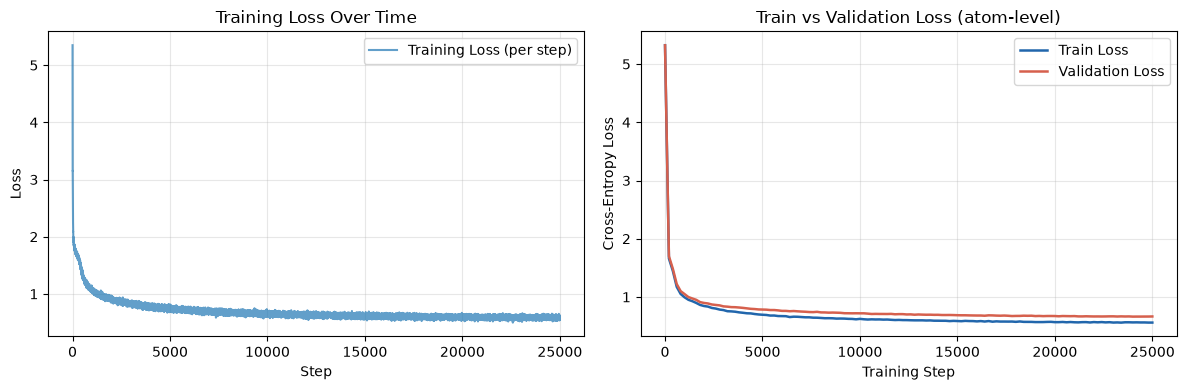

📊 Final Training Loss: 0.5596
📊 Final Validation Loss: 0.6646
💾 Updated training_config_atom-level.json with final loss values

🧪 Quick generation sanity check...
Generated samples: ['CCc1nc2ccc(O)cc2cc1c3ccc(cc3)S(=O)(=O)N(Cc4ccccc4)Cc5ccccc5', 'Fc1ccccc1C(=O)N2CCC(CC2)c3cnc(NCc4cccnc4)s3', 'OC(=O)COc1ccc(\\C=C\\2/COc3ccccc3C2=O)cc1', 'Fc1cc2CCc3cc(ncc3c2cc1Cl)C(=O)NCCCN4CCN(CC4)c5ccccc5Cl', 'CC[C@@]1(O)[C@@H](C[C@H]2[C@@H]1[C@]3(C)CCC(=O)O[C@@H]3O)OC(=O)C']


In [16]:
resume_training = os.path.exists(save_path)
start_iter = 0

if resume_training:
    print(f"🔄 Resuming from checkpoint: {save_path}")
    try:
        checkpoint = torch.load(save_path, map_location=device)
        if isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_iter = checkpoint.get('iteration', 0)
            print(f"📍 Resuming from iteration {start_iter}")
        else:
            model = checkpoint
            model.to(device)
            print("📍 Loaded legacy checkpoint")
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        print("🔄 Starting fresh training...")
        resume_training = False

losses = []
train_losses = []
val_losses = []
eval_step_numbers = []     # NEW: explicit step number per eval point, for CSV export
start_time = time.time()

print(f"🚀 Starting training for {max_iters} iterations...")
print(f"📊 Batch size: {batch_size}, Block size: {block_size}")
print(f"🧠 Model: {trainable_params/1e6:.1f}M parameters")

for iter_num in range(start_iter, max_iters):
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses_dict = estimate_loss()
        train_loss = losses_dict['train']
        val_loss = losses_dict['val']
        train_losses.append(float(train_loss))
        val_losses.append(float(val_loss))
        eval_step_numbers.append(iter_num)
        elapsed_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Step {iter_num:5d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"LR: {current_lr:.2e} | Time: {elapsed_time:.1f}s")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())

    if iter_num % save_interval == 0 or iter_num == max_iters - 1:
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'iteration': iter_num,
            'eval_step_numbers': eval_step_numbers,   # raw data saved INSIDE the checkpoint too
            'train_losses': train_losses,
            'val_losses': val_losses,
            'config': {
                'vocab_size': vocab_size, 'block_size': block_size, 'n_embd': n_embd,
                'n_head': n_head, 'n_layer': n_layer, 'dropout': dropout,
            }
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at iteration {iter_num}")

total_time = time.time() - start_time
print(f"\n✅ Training completed!")
print(f"⏱️ Total training time: {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"🚀 Average time/iteration: {total_time/max_iters:.3f}s")

# --- Save raw loss-curve data to CSV (reproducibility / auditability) ---
csv_path = f"loss_curve_data_{TOKENIZER_NAME}.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "train_loss", "val_loss"])
    for s, tr, va in zip(eval_step_numbers, train_losses, val_losses):
        writer.writerow([s, tr, va])
print(f"💾 Saved raw loss curve data: {csv_path}")

# --- Plot directly from the in-memory lists populated during THIS training run ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.7, label='Training Loss (per step)')
plt.title('Training Loss Over Time'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(eval_step_numbers, train_losses, '-', color='#2166AC', linewidth=1.8, label='Train Loss')
plt.plot(eval_step_numbers, val_losses, '-', color='#D6604D', linewidth=1.8, label='Validation Loss')
plt.title(f'Train vs Validation Loss ({TOKENIZER_NAME})')
plt.xlabel('Training Step'); plt.ylabel('Cross-Entropy Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"loss_curve_{TOKENIZER_NAME}.png", dpi=300)
plt.show()

print(f"📊 Final Training Loss: {train_losses[-1]:.4f}")
print(f"📊 Final Validation Loss: {val_losses[-1]:.4f}")

training_config.update({
    "final_train_loss": round(float(train_losses[-1]), 4),
    "final_val_loss": round(float(val_losses[-1]), 4),
    "total_training_time_sec": round(total_time, 1),
})
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"💾 Updated training_config_{TOKENIZER_NAME}.json with final loss values")

print(f"\n🧪 Quick generation sanity check...")
test_samples = generate_smiles(model, n_samples=10, temperature=0.8)
print(f"Generated samples: {test_samples[:5]}")

## Evaluation setup: QED / SA score dependencies

Downloads RDKit's official Synthetic Accessibility (SA) score implementation
(Ertl & Schuffenhauer, *J. Cheminformatics* 2009).

In [17]:
sascorer_path = "sascorer.py"
fpscores_path = "fpscores.pkl.gz"

if not os.path.exists(sascorer_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py",
        sascorer_path)
if not os.path.exists(fpscores_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz",
        fpscores_path)

sys.path.append(os.getcwd())
import sascorer

_test_mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
print(f"✅ SA score sanity check (aspirin): {sascorer.calculateScore(_test_mol):.3f}")
print(f"✅ QED sanity check (aspirin): {QED.qed(_test_mol):.3f}")

✅ SA score sanity check (aspirin): 1.580
✅ QED sanity check (aspirin): 0.550


In [18]:
from utils import (
    n_chars,
    check_validity,
    check_novelty,
    strsmis2listsmis,
    list2txt,
    get_props,
)

def load_training_smiles(file_path):
    try:
        with open(file_path, 'r') as f:
            text = f.read()
        training_smiles = []
        current_smi = ""
        in_smiles = False
        for char in text:
            if char == '<':
                in_smiles = True
                current_smi = ""
            elif char == '>':
                if in_smiles and current_smi:
                    training_smiles.append(current_smi)
                in_smiles = False
                current_smi = ""
            elif in_smiles:
                current_smi += char
        print(f"Loaded {len(training_smiles)} training SMILES")
        return list(set(training_smiles))
    except Exception as e:
        print(f"Error loading training data: {e}")
        return []

training_data_path = 'data_for_generation_mol.txt'
training_smiles = load_training_smiles(training_data_path)

Loaded 1498669 training SMILES


In [19]:
def generate_diverse_smiles(model, n_samples=500, temperature_range=(0.7, 1.2), max_length=100, verbose=False):
    model.eval()
    sos_token = encode('<')[0]
    eos_token = encode('>')[0]
    generated_smiles = []
    for i in range(n_samples):
        temp = random.uniform(temperature_range[0], temperature_range[1])
        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
            generated = model.generate(context, max_new_tokens=max_length, eos_token=eos_token,
                                        temperature=temp, top_k=random.randint(30, 100))
            smi = decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()
            if smi and len(smi) > 5:
                generated_smiles.append(smi)
        except Exception:
            continue
        if verbose and i % 100 == 0:
            print(f"  Generated {i}/{n_samples}...")
    model.train()
    return generated_smiles

## Benchmark functions (validity → uniqueness → novelty, + QED/SA/MW)

In [20]:
def check_validity_batch(smiles_list):
    valid_smiles = []
    for smi in smiles_list:
        if check_validity(smi):
            valid_smiles.append(smi)
    return valid_smiles

def check_uniqueness_correct(smiles_list):
    return list(set(smiles_list))

def check_novelty_correct(generated_smiles, training_smiles):
    novel_smiles = []
    training_set = set(training_smiles)
    for smi in generated_smiles:
        if smi not in training_set:
            novel_smiles.append(smi)
    return novel_smiles

def calculate_diversity_tanimoto(smiles_list, sample_size=1000):
    if len(smiles_list) < 2:
        return 0.0
    smiles_sample = random.sample(smiles_list, sample_size) if len(smiles_list) > sample_size else smiles_list
    fps = []
    for smi in smiles_sample:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=2048))
    if len(fps) < 2:
        return 0.0
    similarities = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            similarities.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1 - np.mean(similarities)

def compute_drug_likeness(smiles_list):
    count = 0
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                hbd = Descriptors.NumHDonors(mol)
                hba = Descriptors.NumHAcceptors(mol)
                if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
                    count += 1
        except Exception:
            continue
    return count / len(smiles_list) if smiles_list else 0.0

def compute_qed_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(QED.qed(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_sa_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(sascorer.calculateScore(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_mw_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(Descriptors.MolWt(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

## Multi-run benchmark (10 runs × 500 molecules = 5,000 total generations)

In [21]:
def run_multi_run_benchmark(model, n_runs=10, n_samples=500, save_prefix=None):
    save_prefix = save_prefix or TOKENIZER_NAME
    per_run_results = []

    for run_idx in range(n_runs):
        print(f"\n{'='*60}\nRUN {run_idx+1}/{n_runs}\n{'='*60}")
        generated = generate_diverse_smiles(model, n_samples=n_samples)
        print(f"Raw generated: {len(generated)}")

        valid = check_validity_batch(generated)
        validity = len(valid) / len(generated) if generated else 0.0
        print(f"Validity: {validity:.2%} ({len(valid)}/{len(generated)})")

        if not valid:
            per_run_results.append({
                "run": run_idx, "n_generated": len(generated), "validity": validity,
                "uniqueness": 0.0, "novelty": 0.0, "diversity": 0.0, "drug_likeness": 0.0,
                "qed_mean": 0.0, "sa_mean": 0.0, "mw_mean": 0.0,
            })
            continue

        unique = check_uniqueness_correct(valid)
        uniqueness = len(unique) / len(valid) if valid else 0.0
        print(f"Uniqueness: {uniqueness:.2%} ({len(unique)}/{len(valid)})")

        novel = check_novelty_correct(unique, training_smiles) if training_smiles else unique
        novelty = len(novel) / len(unique) if unique else 0.0
        print(f"Novelty: {novelty:.2%} ({len(novel)}/{len(unique)})")

        diversity = calculate_diversity_tanimoto(novel) if len(novel) > 1 else 0.0
        drug_likeness = compute_drug_likeness(novel)
        qed_stats = compute_qed_stats(novel)
        sa_stats = compute_sa_stats(novel)
        mw_stats = compute_mw_stats(novel)

        print(f"Diversity: {diversity:.4f} | Drug-likeness: {drug_likeness:.2%} | "
              f"QED: {qed_stats['mean']:.3f} | SA: {sa_stats['mean']:.3f} | MW: {mw_stats['mean']:.1f}")

        per_run_results.append({
            "run": run_idx, "n_generated": len(generated), "validity": validity,
            "uniqueness": uniqueness, "novelty": novelty, "diversity": diversity,
            "drug_likeness": drug_likeness,
            "qed_mean": qed_stats["mean"], "sa_mean": sa_stats["mean"], "mw_mean": mw_stats["mean"],
        })

    def agg(key):
        vals = [r[key] for r in per_run_results]
        return float(np.mean(vals)), float(np.std(vals))

    summary = {}
    for key in ["validity", "uniqueness", "novelty", "diversity", "drug_likeness",
                "qed_mean", "sa_mean", "mw_mean"]:
        mean, std = agg(key)
        summary[key] = {"mean": mean, "std": std}

    print(f"\n{'='*60}\nFINAL SUMMARY — {TOKENIZER_NAME} (n_runs={n_runs}, n_samples/run={n_samples})\n{'='*60}")
    for key, v in summary.items():
        print(f"{key:15s}: {v['mean']:.4f} ± {v['std']:.4f}")

    output = {
        "tokenizer": TOKENIZER_NAME,
        "n_runs": n_runs,
        "n_samples_per_run": n_samples,
        "per_run_results": per_run_results,
        "summary": summary,
    }
    with open(f"benchmark_results_{save_prefix}.json", "w") as f:
        json.dump(output, f, indent=2)
    print(f"\n💾 Saved benchmark_results_{save_prefix}.json")

    return output

## Load trained model and run the full benchmark

In [22]:
def load_model(checkpoint_path, device=device):
    model = DrugGPT()
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict):
        state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    else:
        state_dict = checkpoint.state_dict()
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    return model

model = load_model(f"drugGPT_{TOKENIZER_NAME}.pt")
print(f"✅ Loaded trained model: drugGPT_{TOKENIZER_NAME}.pt")

✅ Loaded trained model: drugGPT_atom-level.pt


In [23]:
# NOTE: n_runs=10, n_samples=500 -> 5,000 total generations. Adjust down while
# debugging (e.g. n_runs=3, n_samples=50), but use the full setting for numbers
# that go into the paper.
results = run_multi_run_benchmark(model, n_runs=10, n_samples=500)


RUN 1/10
Raw generated: 500
Validity: 93.00% (465/500)
Uniqueness: 100.00% (465/465)
Novelty: 98.28% (457/465)
Diversity: 0.9103 | Drug-likeness: 75.05% | QED: 0.566 | SA: 2.801 | MW: 397.0

RUN 2/10
Raw generated: 500
Validity: 93.60% (468/500)
Uniqueness: 100.00% (468/468)
Novelty: 96.79% (453/468)
Diversity: 0.9105 | Drug-likeness: 76.38% | QED: 0.582 | SA: 2.849 | MW: 391.8

RUN 3/10
Raw generated: 500
Validity: 96.60% (483/500)
Uniqueness: 100.00% (483/483)
Novelty: 96.69% (467/483)
Diversity: 0.9072 | Drug-likeness: 74.73% | QED: 0.553 | SA: 2.793 | MW: 403.6

RUN 4/10
Raw generated: 500
Validity: 92.80% (464/500)
Uniqueness: 100.00% (464/464)
Novelty: 97.41% (452/464)
Diversity: 0.9107 | Drug-likeness: 72.57% | QED: 0.552 | SA: 2.876 | MW: 402.4

RUN 5/10
Raw generated: 500
Validity: 91.40% (457/500)
Uniqueness: 100.00% (457/457)
Novelty: 97.81% (447/457)
Diversity: 0.9074 | Drug-likeness: 76.06% | QED: 0.583 | SA: 2.802 | MW: 398.8

RUN 6/10
Raw generated: 500
Validity: 93.20%